In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el dataset
df = pd.read_csv("i40 (datos).csv")

# Definimos las columnas numéricas con sus nombres reales (incluyendo unidades)
cols = ['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']

In [3]:
# Visualizar los primeros registros del dataframa
df.head()

,idx,parent_device_id,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
0,0,5291,L,303.80,313.30,1406,52.10,166,normal
1,1,3908,L,302.30,311.20,1633,36.40,114,normal
2,2,10767,M,302.27,311.47,1228,68.75,187,failure
3,3,15484,L,302.35,311.93,1522,36.99,214,failure
4,4,784,L,296.70,307.90,1743,27.90,55,normal


In [4]:
# Vemos información sobre el dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14521 entries, 0 to 14520
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   idx               14521 non-null  int64  
 1   parent_device_id  14521 non-null  int64  
 2   product_type      14521 non-null  str    
 3   air_temp [K]      14481 non-null  float64
 4   process_temp [K]  14521 non-null  float64
 5   speed [RPM]       14521 non-null  int64  
 6   torque [Nm]       14521 non-null  float64
 7   tool_wear [min]   14521 non-null  int64  
 8   target            14521 non-null  str    
dtypes: float64(3), int64(4), str(2)
memory usage: 1021.1 KB


In [5]:
# Consultamos forma del Datasheet
df.shape

(14521, 9)

In [6]:
print("Resumen estadístico:")
df[cols].describe().T

Resumen estadístico:


,count,mean,std,min,25%,50%,75%,max
air_temp [K],14481.0,300.478975,1.952737,295.3,298.90,300.60,302.20,304.5
process_temp [K],14521.0,310.165287,1.329586,305.7,309.20,310.32,311.09,313.8
speed [RPM],14521.0,1513.389436,313.604170,-1.0,1354.00,1423.00,1561.00,2886.0
torque [Nm],14521.0,44.955809,14.226641,3.8,35.99,46.70,55.00,76.6
tool_wear [min],14521.0,124.921700,70.105992,0.0,64.00,127.00,193.00,253.0


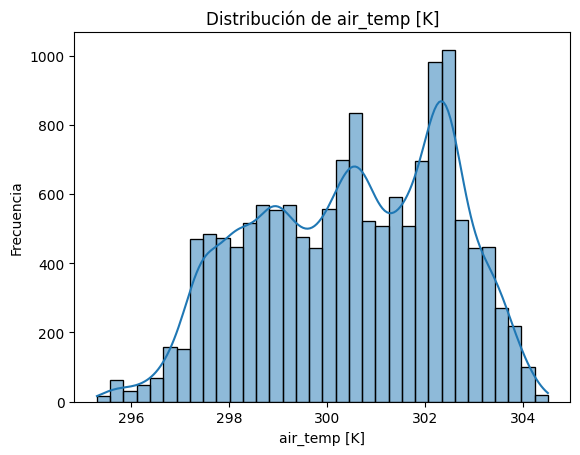

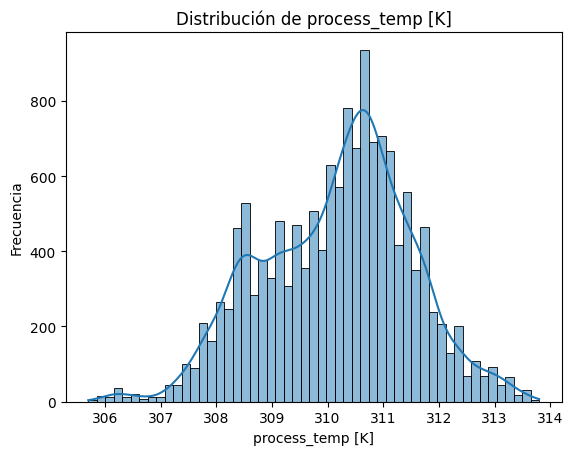

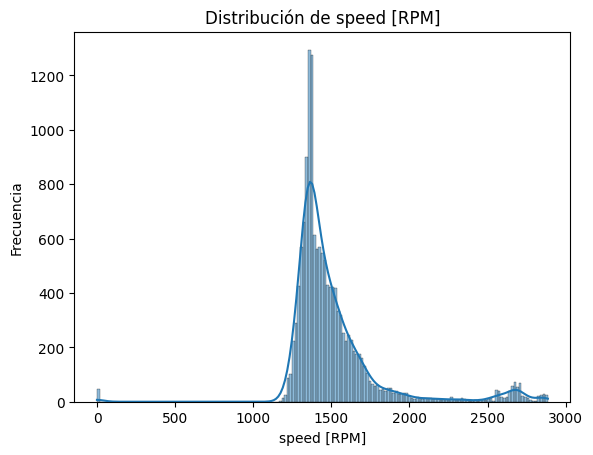

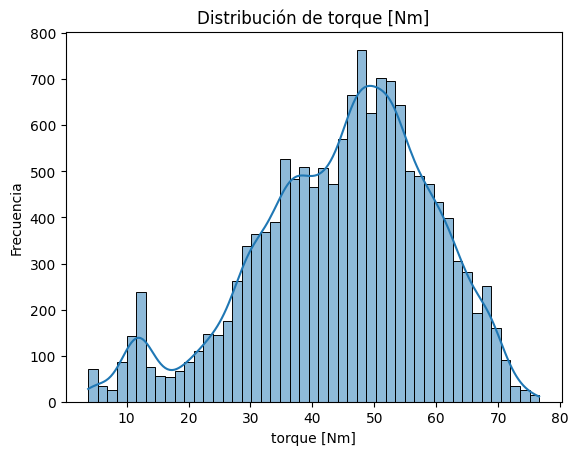

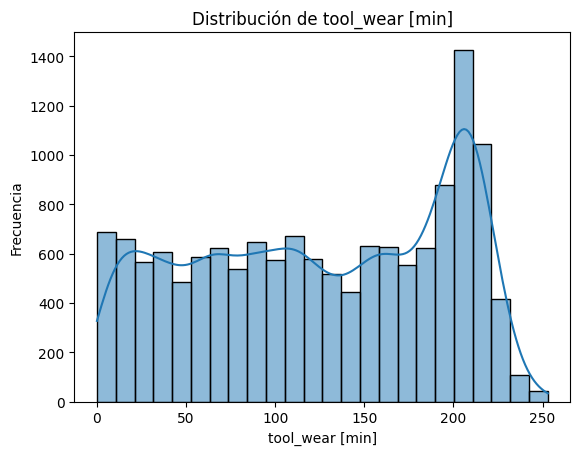

In [7]:
# Distribución de var 
for col in cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

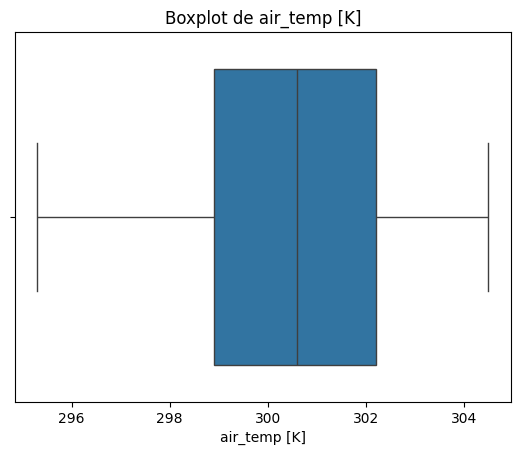

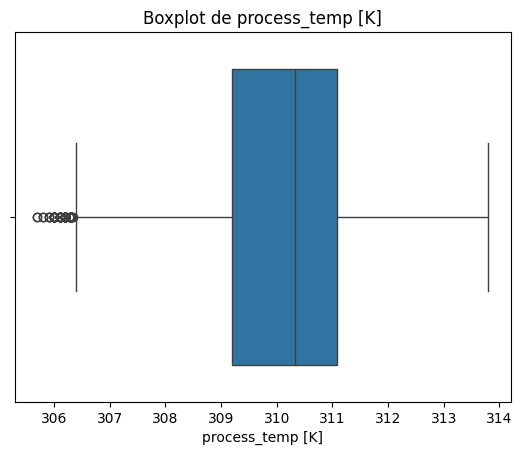

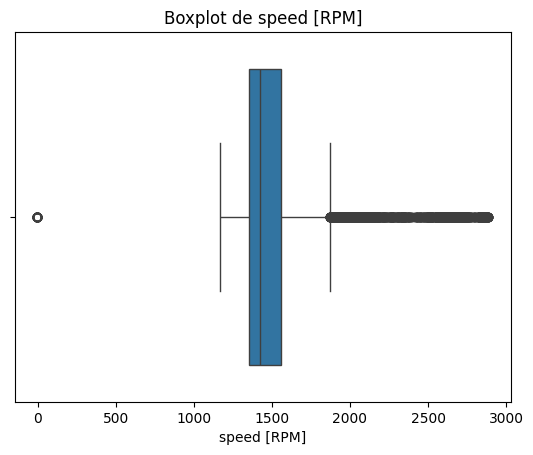

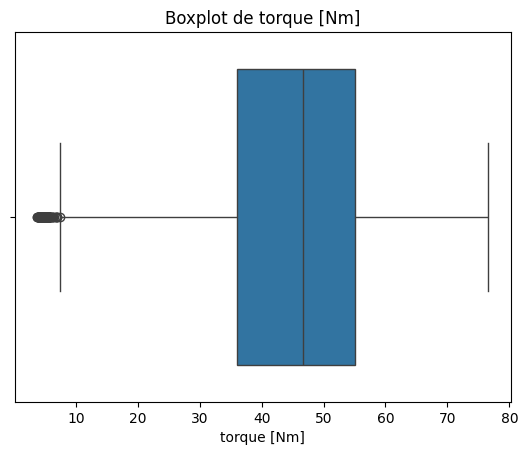

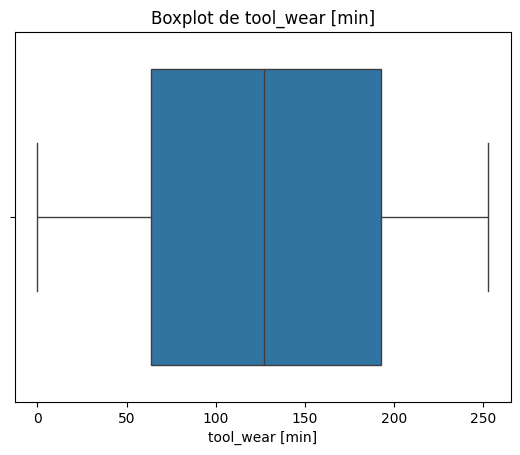

In [ ]:
# Medidas de dispersión 
# Boxplots. Muestra la distribución de los datos, identificando mediana, cuartiles y valores extremos (ver presentación de la catedra)
for col in cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

In [ ]:
# Proporciones
# Var objetivo, cuenta los casos 
df['target'].value_counts()

target
failure    7482
normal     7039
Name: count, dtype: int64

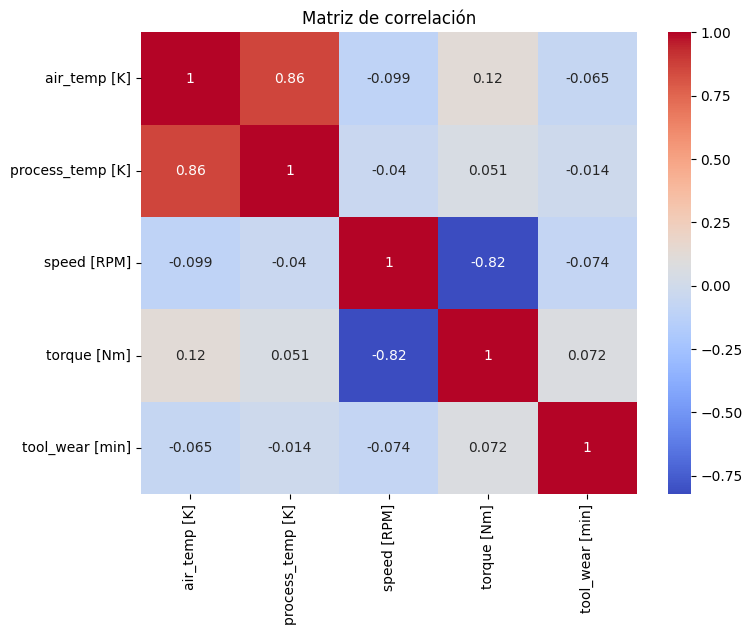

In [10]:
# Correlación entre var 
corr = df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

In [ ]:
# Relación entre var
sns.scatterplot(x='torque', y='tool_wear', hue='target', data=df)
plt.title("Torque vs Tool Wear")
plt.show()

In [ ]:
# Relación entre var 
sns.scatterplot(x='speed', y='torque', hue='target', data=df)
plt.title("Speed vs Torque")
plt.show()